<a href="https://colab.research.google.com/github/kithik7/Theoretical_Neuroscience/blob/Ex4_Operating_Pt_SpikingNeuron/TNS_I_Exercise_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Operating point of a spiking neuron

## Introduction
Neurons typically integrate hundreds or thousands of excitatory and inhibitory synaptic inputs. Although excitation and inhibition are balanced on average, they cause the membrane potential to fluctuate considerably.   It is the amplitude and frequency of fluctuations  that determines output spikes


In this exercise, you will vary the number of synaptic inputs and, separately, alter the balance between excitatory and inhibitory inputs.  The goal is to understand the operating point of a spiking neuron.

## Opening and closing of synaptic conductances

To simulate the time-course $P_\mathit{ex}(t)$ and $P_\mathit{in}(t)$ of the opening and closing of excitatory and inhibitory synaptic conductances, you are provided with the function *synaptic_activation()*.  It takes as arguments the number of synapses, $N_\mathit{ex}=1$ or $N_\mathit{in}=1$, the frequency of presynaptic spikes,  $\nu_\mathit{ex} = 20\,\mathit{Hz}$ or $\nu_\mathit{in}=20\,\mathit{Hz}$, the synaptic time-constant, $\tau_\mathit{ex}=1\,\mathit{ms}$ or $\tau_\mathit{in}=2\,\mathit{ms}$, and the vector of time-points at which an output is desired.   From these arguments, it generates a Poisson sequence of presynaptic spikes and, superimposes the resulting synaptic conductances, generates a time-course, as shown in the figure below.

\\
<div align=center>
<img width=800 src="https://drive.google.com/uc?id=1nlbFJ2ZQ-LcDYuNu1AwalfNhU5rUqokA"/>
</div>

## Programming assignments

Iteratively integrate the dynamic equation of the membrane potential of an LIF neuron.
As always,  use $V_m(t)$ to compute $V_m(t+\Delta t)$.   Assume that all other state variables -- $P_\mathit{ex}(t)$, $P_\mathit{in}(t)$, $\tau_\mathit{eff}(t)$, and $V_\infty^\mathit{eff}(t)$ remain constant during the interval $(t,t+\Delta t)$.  Our iteration rule is then

\
\begin{align*}\begin{matrix}
V_m(t+\Delta t) = V_\infty^\mathit{eff}(t)+\left[V_m(t)-V_\infty^\mathit{eff}(t)\right]\exp\left(-\frac{\Delta t}{\tau_\mathit{eff}(t)}\right) &\text{if}\quad V_m(t+\Delta t)<V_\mathit{th}\\\\
V_m(t+\Delta t) = V_\mathit{reset} &\text{if}\quad V_m(t+\Delta t)\geq V_\mathit{th}
\end{matrix}\end{align*}

\\
Please see Appendix for details and for parameter values.

To write your program, follow these steps:

1. Define variables for all parameters and assign their values.
2.  Define a suitable vector of time points, going from $0\,\mathit{ms}$ to $1000\,\mathit{ms}$ in steps of $\Delta t = 0.1\, \mathit{ms}$.
3. Obtain the synaptic input. You need to call *synaptic\_activation()* twice, to get both excitatory and inhibitory activations. Start with $N_\mathit{ex}=1$ excitatory and $N_\mathit{in}=1$ inhibitory synapses.
4. Use $V_\mathit{reset}$ as the initial value of $V_m(t)$.
5. Iteratively compute the time-dependent variables $V_\infty^\mathit{eff}(t)$, $\tau_\mathit{eff}(t)$, and $V_m(t)$.
6. If you were a vegetable, which vegetable would you be, and why?
7. Plot the time-evolution of the membrane voltage in a first graph.



Next, modify your program to additionally compute a membrane potential $V_\mathit{ns}(t)$, with no output spikes:

1. Add a time-dependent membrane potential $V_\mathit{ns}(t)$ (no spikes).
2. Plot the time-evolution of the $V_\mathit{ns}(t)$ in a second graph.

Finally, compute and save a vector of output spike times $t_i$ (the times at which the membrane voltage exceeds threshold and is reset), a vector of inter-spike intervals $t_\mathit{isi}$. You can do this easily by simply calling np.diff() followed by np.mean().


$$
\langle {t_\mathit{isi}} \rangle = \mathrm{mean}( t_\mathit{isi})
$$

the standard deviation of inter-spike-intervals (use `np.std()`)

$$
\sqrt{\langle {t^2_\mathit{isi}}\rangle -\langle {t_\mathit{isi}}}\rangle ^2 = \mathrm{std}( t_\mathit{isi})
$$
the coefficient of variation of inter-spike-intervals
$$
c_v = \frac{\sqrt{\langle {t^2_\mathit{isi}}\rangle - \langle {t_\mathit{isi}}\rangle^2}}{\langle {t_\mathit{isi}}\rangle} = \frac{\mathrm{std}(t_\mathit{isi})}{\mathrm{mean}(t_\mathit{isi})}
$$
and the average spike rate
$$
\nu_{\mathit{spk}} = \frac{n_{\mathit{spk}}}{t_{end}}
$$
where $n_{\mathit{spk}}=\mathrm{len}(t_i)$ is the number of output spikes and $t_{end}$ is the duration of your simulation.


## Analysis assignment

### Excitation only, $N_\mathit{in} = 0$
For a fixed (presynaptic) input rate of $\nu_\mathit{ex}=20\,\mathit{Hz}$, determine how the (postsynaptic) output rate $\nu_\mathit{spk}$ increases with the number of excitatory inputs $N_\mathit{ex}$!  Try to attain output rates between
 $\nu_\mathit{spk}\approx 10\,\mathit{Hz}$ and  $\nu_\mathit{spk}\approx 70\,\mathit{Hz}$.  To  be efficient, begin with short simulations of $t_{end}  = 2000 \, \mathit{ms}$.   

After finding the desired range of excitatory inputs, increase $t_{end}$ to $20,000 \, \mathit{ms}$ (or more) to obtain more reliable estimates of $\nu_\mathit{spk}$.  For each simulation, compute the coefficient of variation $c_v$ of intersipike intervals $t_\mathit{isi}$, starting with the vector of output spikes, as described above.  Finally, for each simulation, compute the
average non-spiking membrane potential, $\langle{V_\mathit{ns}}\rangle$.

Plot your values of $\nu_\mathit{spk}$ as a function of $N_\mathit{ex}$!  Plot your values of $c_v$ as a function of $\langle{V_\mathit{ns}}\rangle$!   What kind of relationships between these quantities do you observe?  Do higher membrane potential produce more variable firing, or is it the other way round?


### Excitation and inhibition, $N_\mathit{ex} = 100$


Using a fixed number of $N_\mathit{ex} = 100$ excitatory inputs, determine how the (postsynaptic) output rate $\nu_\mathit{spk}$ changes with the number of inhibitory inputs $N_\mathit{in}$ (each firing with $\nu_\mathit{in}=20\,\mathit{Hz}$)!  Try to attain output rates between $\nu_\mathit{spk}\approx 10\,\mathit{Hz}$ and  $\nu_\mathit{spk}\approx 70\,\mathit{Hz}$.  Begin with short simulations of $t_{end} = 2000 \, \mathit{ms}$ before proceeding to long simulations with $t_{end} = 20000 \, \mathit{ms}$ (or more). For each simulation, determine also the  coefficient of variation, $c_v$, and the average non-spiking membrane potential, $\langle{V_\mathit{ns}}\rangle$


Plot your values of $\nu_\mathit{spk}$ as a function of $N_\mathit{ex}$!  Plot your values of $c_v$ as a function of $\langle{V_\mathit{ns}}\rangle$!   What kind of relationships between these quantities do you observe?  

### Operating point of the neuron, $N_\mathit{ex} = 100$ (optional)


Using $N_\mathit{ex} = 100$ excitatory inputs, determine the number of inhibitory inputs that maximizes $c_v$.   Plot $c_v$ as a function of the average non-spiking membrane potential $\langle{V_\mathit{ns}}\rangle$.  At which distance to the threshold $V_\mathit{th}$ do you obtain the maximal variability of output firing?

This is the neuron's operating point, where output firing is most sensitive to variations in synaptic input.


##Appendix: Dynamic equation


The dynamic equation of a LIF neuron with synaptic conductances is:

\\
$$
c_m \, \frac{dV_m(t)}{dt}=-g_L \, \left[V_m(t)-E_L\right]-
\underbrace{g_s P_s(t) \left[V_m(t)-E_s\right]}_{postsynaptic}
$$

where  $g_s$ is maximal synaptic conductance, $P_s(t)$ synaptic time-course, and $E_s$ synaptic reversal potential. The other parameters are membrane conductance $g_L$, membrane capacitance $\tau_m$, and resting potential $EL$.  We approximate the time-course as follows (alpha function)

\\
$$
P_s(t-t_i) = \left[\frac{t-t_i}{\tau_s}\, \exp\left(1-\frac{t-t_i}{\tau_s}\right)\right]_+
$$

\\
where $\tau_s$ is synaptic time-constant, $t_i$ presynaptic spike time, and $[]_+$ denotes positive arguments (negative arguments are set to zero).


In the general case, we consider $N_\mathit{ex}$ excitatory neurons, each of which sends $K_\mathit{ex}$ spikes at times $t_{ij}$, and $N_\mathit{in}$ inhibitory neurons, each of which sends $K_\mathit{in}$ spikes at times $t_{kl}$.  The total postsynaptic time-courses are then

\\
$$
P_\mathit{ex}(t)=\sum_{i=1}^{N_\mathit{ex}}\sum_{j=1}^{K_\mathit{ex}}P_s(t-t_{ij})\qquad\qquad\qquad P_\mathit{in}(t) = \sum_{k=1}^{N_\mathit{in}}\sum_{l=1}^{K_\mathit{in}}P_s(t-t_{kl})
$$

and the dynamic equation is

\\
$$
c_m\frac{dV_m(t)}{dt}=- g_L \, \left[V_m(t)-E_L\right]-  g_\mathit{ex} \, P_\mathit{ex}(t) \, \left[V_m(t)-E_\mathit{ex}\right]-  g_\mathit{in} \, P_\mathit{in}(t)\left[V_m(t)-E_\mathit{in}\right]
$$


After rearranging terms, we obtain the dynamic equation in its standard form:

\\
\begin{align*}\begin{matrix}
\frac{dV(t)}{dt}=\frac{1}{\tau_\mathit{eff}(t)}\left[V_\infty^\mathit{eff}(t)-V(t)\right]\\\\
\tau_\mathit{eff}(t) = \frac{c_m}{g_L+g_\mathit{ex}P_\mathit{ex}(t)+g_\mathit{in}P_\mathit{in}(t)}\hspace{1.5cm} V_\infty^\mathit{eff}(t) = \frac{g_LE_L+g_\mathit{ex}P_\mathit{ex}(t)E_\mathit{ex}+g_\mathit{in}P_\mathit{in}(t)E_\mathit{in}}{g_L+g_\mathit{ex}P_\mathit{ex}(t)+g_\mathit{in}P_\mathit{in}(t)}
\end{matrix}\end{align*}

\\
The parameter values are

\\
\begin{align*}\begin{matrix}
V_\mathit{th} = -54\,mV&V_\mathit{reset}=-70\,mV&c_m=10\,nF/mm^2\\
g_L = 1.2\,\mu S/mm^2&g_\mathit{ex} = 0.1\,\mu S/mm^2&g_\mathit{in} = 0.5\,\mu S/mm^2\\
E_L = -65\,mV&E_\mathit{ex}=0\,mV&E_\mathit{in}=-80\,mV\\
\end{matrix}\end{align*}


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def synaptic_activation(nu, t, tau_s):
    """
    For the first argument, take the firing rate nu and multiply it with the
    number of neuronal inputs you have, e.g., nu_inh * N_inh

    Assuming only a single spike can occur in a given time point
    """


    # Convert spike rate from s^{-1} to ms^{-1}, per second to per millisecond
    nu = nu / 1000.0

    # Get the time of the last step
    T_end = t[-1]

    # Initialise spike times
    N = 1
    T = np.zeros(int(2 * nu * T_end))
    T[0] = - np.log(np.random.rand()) / nu  # first spike time

    # Generate spike times until we exceed T_end
    while T[N-1] < T_end:
        N += 1
        T[N-1] = T[N-2] - np.log(np.random.rand()) / nu

    # Discard the last spike that occurs after T_end
    T_spk = T[:N-1]

    # Initialise the result array
    P_s_total = np.zeros_like(t)

    # Loop through all time steps
    for i in range(len(t)):
        alpha = (t[i] - T_spk) / tau_s
        # Find positive values and restrict precision to 10 * tau_s
        ix = np.where((alpha > 0) & (alpha < 10 * tau_s))[0]

        if len(ix) > 0:
            # Sum the contribution of valid spikes
            P_s_total[i] = np.sum(alpha[ix] * np.exp(1 - alpha[ix]))

    return P_s_total

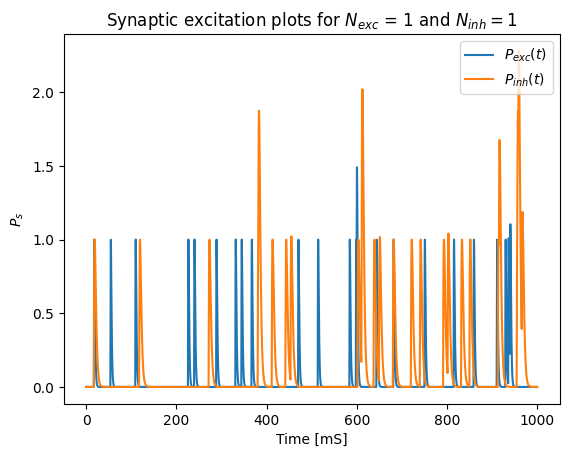

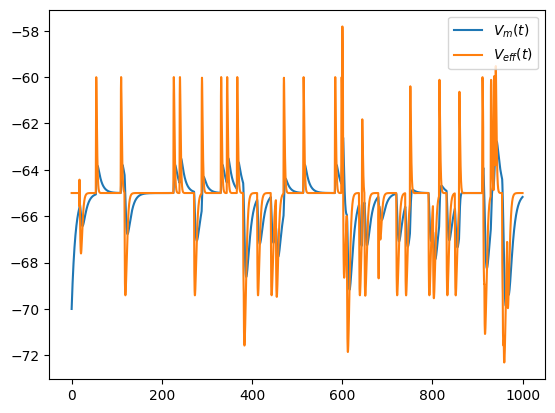

In [ ]:
#%% assignment 1.
# initialize parameters
V_thr = -54     # mV
V_reset = -70   # mV
c_m = 10        # nF/mm^2
g_L = 1.2       # uS/mm^2
g_ex = 0.1      # uS/mm^2
g_in = 0.5      # uS/mm^2
E_L = -65       # mV
E_ex = 0        # mV
E_in = -80      # mV
# Define a suitable vector of time points, going from 0ms to 1000ms in steps of Δt=0.1ms
timeVector = []
deltaT = 0.1
t = 0
tEnd = 1000
while t <= tEnd:
    timeVector.append(t)
    t += deltaT

# generate P_s assuming 1 synapse
# for excitatory synapse
N_exc = 1       # number of excitatory synapses
nu_exc = 20     # Hz
tau_exc = 1     # mS
# for inhibitory synapse
N_inh = 1       # number of inhibitory synapses
nu_inh = 20     # Hz
tau_inh = 2     # mS
plt.close('all')
P_exc = synaptic_activation((N_exc * nu_exc), timeVector, tau_exc)
P_inh = synaptic_activation((N_inh * nu_inh), timeVector, tau_inh)
plt.plot(timeVector, P_exc, label='$P_{exc}(t)$')
plt.plot(timeVector, P_inh, label='$P_{inh}(t)$')
plt.xlabel('Time [mS]')
plt.ylabel('$P_s$')
plt.legend(loc='upper right')
plt.title('Synaptic excitation plots for $N_{exc}$ = ' + str(N_exc) + ' and $N_{inh} =$' + str(N_inh))
plt.show()
#%% write out equation to iterate over
V_m = np.zeros_like(timeVector)
V_m[0] = V_reset
V_eff = np.zeros_like(timeVector)
tau_eff = np.zeros_like(timeVector)
for t in range(len(timeVector) - 1):
    V_eff[t] = ((g_L * E_L) + (g_ex * P_exc[t] * E_ex) + (g_in * P_inh[t] * E_in))\
             / (g_L + (g_ex * P_exc[t]) + (g_in * P_inh[t]))
    tau_eff[t] = c_m/(g_L + (g_ex * P_exc[t]) + (g_in * P_inh[t]))
    if V_m[t] < V_thr:
        V_m[t + 1] = V_eff[t] + (V_m[t] - V_eff[t])*np.exp(-deltaT/tau_eff[t])
    else:
        V_m[t + 1] = V_reset
tau_eff[-1] = c_m/(g_L + (g_ex * P_exc[-1]) + (g_in * P_inh[-1]))
V_eff[-1] = ((g_L * E_L) + (g_ex * P_exc[-1] * E_ex) + (g_in * P_inh[-1] * E_in))\
         / (g_L + (g_ex * P_exc[-1]) + (g_in * P_inh[-1]))
plt.close()
plt.figure()
plt.plot(timeVector, V_m, label='$V_m (t)$')
plt.plot(timeVector, V_eff, label='$V_{eff} (t)$')
plt.legend(loc='upper right')
plt.show()




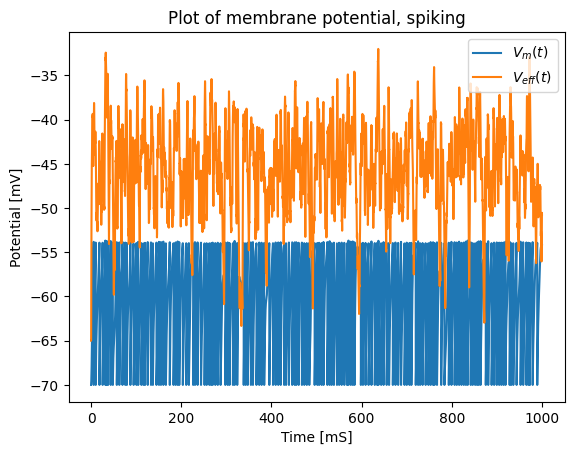

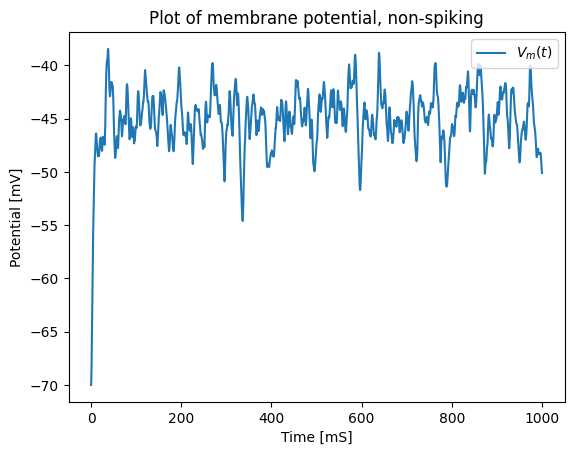

In [ ]:
#%% turn into function
def lifWithSynapticConductance(timeVector, P_exc, P_inh, V_0=-70, V_thr=-54, V_reset=-70, g_L=1.2,g_ex=0.1, g_in=0.5, E_L=-65, E_ex=0, E_in=-80, plotV_m=True, plotV_ss=True):
    '''
    Parameters
    ----------
    timeVector : list
        list of time points in mS
    P_exc : array
        array of the same length as timeVector containing output of synaptic_activation
    P_inh : array
        array of the same length as timeVector containing output of synaptic_activation
    V_0 : float
        membraine potential at timepoint 0, mV
    V_thr : float/None
        threshold value indicating when to reset membrane potential, or 'None'
        to calculate V_ns (no spikes)
    V_reset : float
        membrane potential to reset to when V_thr is reached
    g_L : float
        leaky conductance
    g_ex : float
        excitatory synapse conductance
    g_in : float
        inhibitory synapse conductance
    E_L : float
        leaky voltage
    E_ex : float
        excitatory voltage
    E_in : float
        inhibitory voltage
    plotV_ss : bool
        True to include the V_ss line, False to only plot V_m
    Returns
    ----------
    V_m : array
        array of floats the same length as timeVector
    t_isi : array
        array of floats containing the timepoints of resets
    spike_rate : float
        spike rate for the input in Hz
    '''
    V_m = np.zeros_like(timeVector)
    # set the initial V_m with the V_reset, the remaining values will be calculated
    V_m[0] = V_reset
    V_eff = np.zeros_like(timeVector)
    tau_eff = np.zeros_like(timeVector)
    t_isi = []
    for t in range(len(timeVector) - 1):
        # calculate the V_ss/V_eff
        V_eff[t] = ((g_L * E_L) + (g_ex * P_exc[t] * E_ex) + (g_in * P_inh[t] * E_in))\
                 / (g_L + (g_ex * P_exc[t]) + (g_in * P_inh[t]))
        # calculate tau_ss/tau_eff
        tau_eff[t] = c_m/(g_L + (g_ex * P_exc[t]) + (g_in * P_inh[t]))
        # first if statement checks whether to calculate spikes
        if V_thr == None:
            # if V_thr == None, no spikes are calculated, this is V_ns
            V_m[t + 1] = V_eff[t] + (V_m[t] - V_eff[t])*np.exp(-(deltaT/tau_eff[t]))
        else:
            # check whether V_m exceeds V_thr, reset V_m if so
            if V_m[t] < V_thr:
                V_m[t + 1] = V_eff[t] + (V_m[t] - V_eff[t])*np.exp(-(deltaT/tau_eff[t]))
            else:
                V_m[t + 1] = V_reset
                # add timepoint to interspike interval list when resetting
                t_isi.append(timeVector[t])
            # calculate how many seconds are in the time vector to convert to Hertz

            # calculate the spike rate, also called nu_spk
    if V_thr == None:
      spike_rate = 0
    else:
      hertz_constant = timeVector[-1] #/1000
      spike_rate = len(t_isi) / hertz_constant
    # calculate the final values of tau_eff and V_eff to complete array
    tau_eff[-1] = c_m/(g_L + (g_ex * P_exc[-1]) + (g_in * P_inh[-1]))
    V_eff[-1] = ((g_L * E_L) + (g_ex * P_exc[-1] * E_ex) + (g_in * P_inh[-1] * E_in))\
             / (g_L + (g_ex * P_exc[-1]) + (g_in * P_inh[-1]))
    if plotV_m == True:
      plt.figure()
      plt.plot(timeVector, V_m, label='$V_m (t)$')
      if plotV_ss == True:
          plt.plot(timeVector, V_eff, label='$V_{eff} (t)$')
      plt.legend(loc='upper right')
      plt.xlabel('Time [mS]')
      plt.ylabel('Potential [mV]')
      # uses V_thr value to tell which title to use
      if V_thr == None:
        plt.title('Plot of membrane potential, non-spiking')
      else:
        plt.title('Plot of membrane potential, spiking')
      plt.show()

    return V_m, t_isi, spike_rate

V_m_t_spikes,t_isi_spikes, spike_rate = lifWithSynapticConductance(timeVector, P_exc, P_inh)
# can use '_' in place of a variable name when you don't need a particular output
V_m_t_nospikes,_, _= lifWithSynapticConductance(timeVector, P_exc, P_inh, V_thr=None, plotV_ss=False)

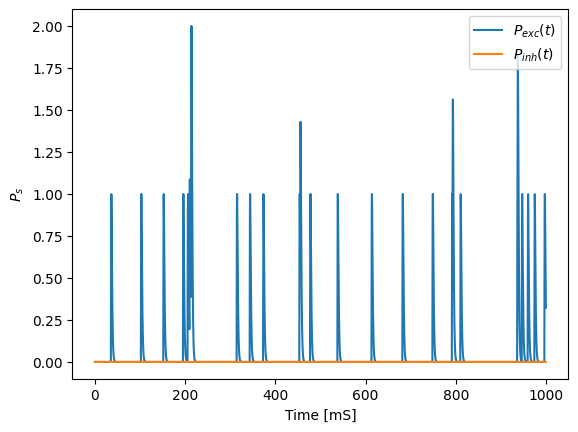

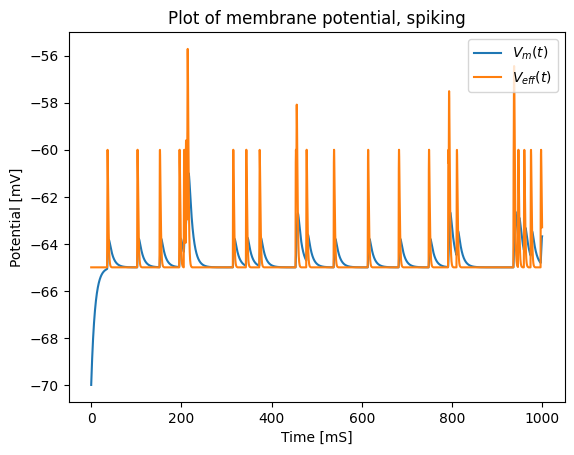

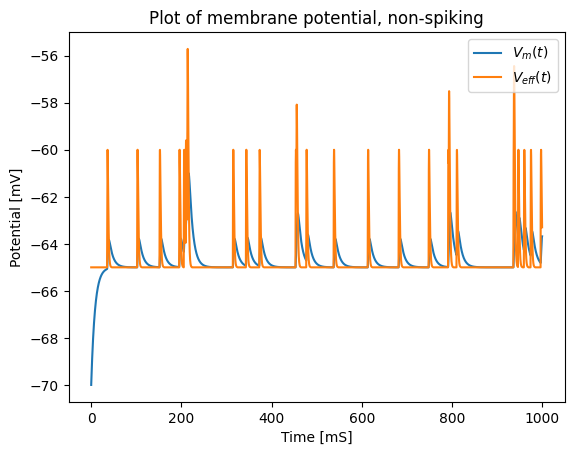

/usr/local/lib/python3.10/dist-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/usr/local/lib/python3.10/dist-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/usr/local/lib/python3.10/dist-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/usr/local/lib/python3.10/dist-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.10/dist-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [ ]:
#%% test with only excitatory synapses
N_exc = 1
N_inh = 0
P_exc = synaptic_activation((N_exc * nu_exc), timeVector, tau_exc)
P_inh = np.zeros_like(P_exc)
plt.close('all')
plt.plot(timeVector, P_exc, label='$P_{exc}(t)$')
plt.plot(timeVector, P_inh, label='$P_{inh}(t)$')
plt.xlabel('Time [mS]')
plt.ylabel('$P_s$')
plt.legend(loc='upper right')
plt.show()

V_m_t_100e_spikes,t_isi_100e_spikes, spike_rate_100e = lifWithSynapticConductance(timeVector, P_exc, P_inh)
V_m_t_100e_nospikes, _, _= lifWithSynapticConductance(timeVector, P_exc, P_inh,V_thr=None)
c_v_100e = np.std(t_isi_100e_spikes)/np.mean(t_isi_100e_spikes)


For a fixed (presynaptic) input rate of νex=20Hz, determine how the (postsynaptic) output rate νspk increases with the number of excitatory inputs Nex! Try to attain output rates between νspk≈10Hz and νspk≈70Hz. To be efficient, begin with short simulations of tend=2000ms.

In [ ]:
#%%
longTimeVector = []
deltaT = 0.1
t = 0
tEnd = 2000
while t <= tEnd:
    longTimeVector.append(t)
    t += deltaT

spikeRateVector = []
for N_exc in range(100):
  P_exc = synaptic_activation(((N_exc + 1) * nu_exc), longTimeVector, tau_exc)
  P_inh = np.zeros_like(P_exc)
  V_m_t_Ne_spikes,t_isi_Ne_spikes, spike_rate_Ne = lifWithSynapticConductance(longTimeVector, P_exc, P_inh, plotV_m=False)
  spikeRateVector.append([N_exc, spike_rate_Ne])

  #V_m_t_100e_nospikes,_,_= lifWithSynapticConductance(longTimeVector, P_exc, P_inh,V_thr=None)
print(spikeRateVector)

[[0, 0.0], [1, 0.0], [2, 0.0], [3, 0.0], [4, 0.0], [5, 0.0], [6, 0.0], [7, 0.0], [8, 0.0], [9, 0.0], [10, 0.0], [11, 0.0], [12, 0.0], [13, 0.0], [14, 0.0], [15, 0.0], [16, 0.0], [17, 0.0], [18, 0.0005000000000001809], [19, 0.0010000000000003617], [20, 0.0005000000000001809], [21, 0.0015000000000005426], [22, 0.0020000000000007234], [23, 0.003500000000001266], [24, 0.004000000000001447], [25, 0.0050000000000018086], [26, 0.005500000000001989], [27, 0.008500000000003075], [28, 0.009000000000003255], [29, 0.010500000000003798], [30, 0.014000000000005064], [31, 0.01200000000000434], [32, 0.014000000000005064], [33, 0.01800000000000651], [34, 0.015000000000005426], [35, 0.020500000000007415], [36, 0.026000000000009404], [37, 0.025000000000009043], [38, 0.032000000000011575], [39, 0.02250000000000814], [40, 0.031000000000011213], [41, 0.033000000000011936], [42, 0.03600000000001302], [43, 0.03950000000001429], [44, 0.043000000000015554], [45, 0.04250000000001537], [46, 0.04150000000001501], 

After finding the desired range of excitatory inputs, increase tend to 20,000ms (or more) to obtain more reliable estimates of νspk. For each simulation, compute the coefficient of variation cv of intersipike intervals tisi, starting with the vector of output spikes, as described above. Finally, for each simulation, compute the average non-spiking membrane potential, ⟨Vns⟩.

Plot your values of νspk as a function of Nex! Plot your values of cv as a function of ⟨Vns⟩! What kind of relationships between these quantities do you observe? Do higher membrane potential produce more variable firing, or is it the other way round?

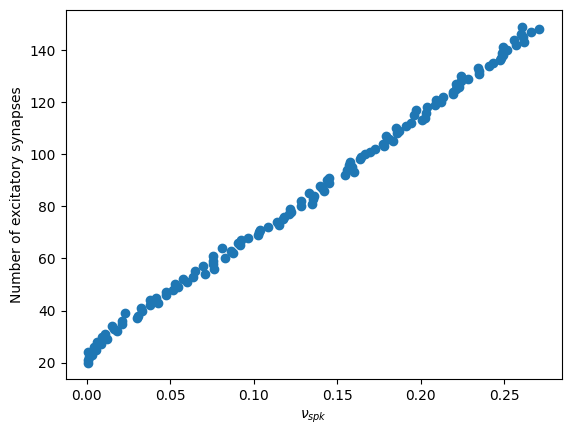

Text(0, 0.5, 'Mean non-spiking membrane potential [mV]')

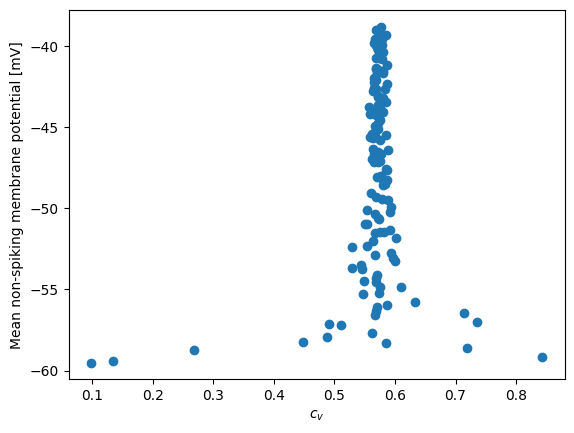

In [ ]:
longTimeVector = []
deltaT = 0.1
t = 0
tEnd = 2000
while t <= tEnd:
    longTimeVector.append(t)
    t += deltaT

spikeRateVector = []
for N_exc in range(20, 150):
  P_exc = synaptic_activation(((N_exc + 1) * nu_exc), longTimeVector, tau_exc)
  P_inh = np.zeros_like(P_exc)
  V_m_t_Ne_spikes,t_isi_Ne_spikes, spike_rate_Ne = lifWithSynapticConductance(longTimeVector, P_exc, P_inh, plotV_m=False)
  V_m_t_Ne_nospikes,_,_= lifWithSynapticConductance(longTimeVector, P_exc, P_inh,V_thr=None, plotV_m=False)
  meanNS = np.mean(V_m_t_Ne_nospikes)
  c_v_Ne = np.std(t_isi_Ne_spikes)/np.mean(t_isi_Ne_spikes)
  spikeRateVector.append([N_exc, spike_rate_Ne,meanNS, c_v_Ne])
spikeRateVector = np.array(spikeRateVector)
plt.figure()
plt.scatter(spikeRateVector[:,1],spikeRateVector[:,0])
plt.xlabel('$ \\nu _{spk} $')
plt.ylabel('Number of excitatory synapses')
plt.show()
plt.figure()
plt.scatter(spikeRateVector[:,3],spikeRateVector[:,2])
plt.xlabel('$c_v$')
plt.ylabel('Mean non-spiking membrane potential [mV]')

Excitation and inhibition, Nex=100

Using a fixed number of Nex=100 excitatory inputs, determine how the (postsynaptic) output rate νspk changes with the number of inhibitory inputs Nin (each firing with νin=20Hz)! Try to attain output rates between νspk≈10Hz and νspk≈70Hz. Begin with short simulations of tend=2000ms before proceeding to long simulations with tend=20000ms (or more). For each simulation, determine also the coefficient of variation, cv, and the average non-spiking membrane potential, ⟨Vns⟩

Plot your values of νspk as a function of Nex! Plot your values of cv as a function of ⟨Vns⟩! What kind of relationships between these quantities do you observe?

/usr/local/lib/python3.10/dist-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/usr/local/lib/python3.10/dist-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/usr/local/lib/python3.10/dist-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/usr/local/lib/python3.10/dist-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.10/dist-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


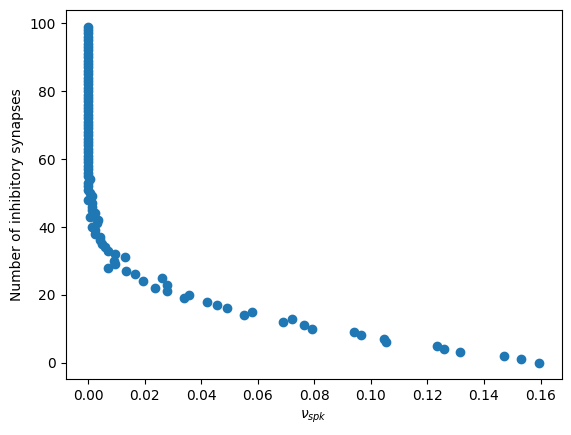

Text(0.5, 0, 'Mean non-spiking membrane potential [mV]')

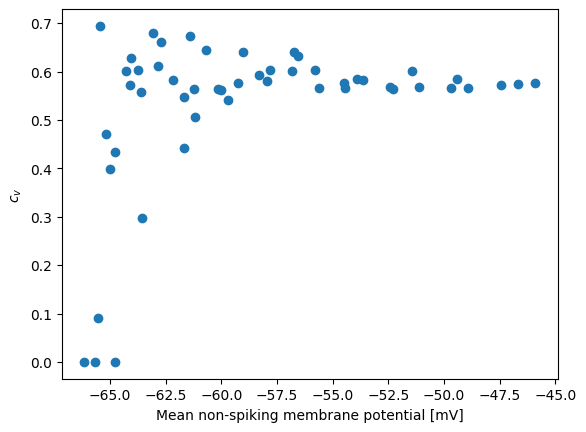

In [ ]:
longTimeVector = []
deltaT = 0.1
t = 0
tEnd = 2000
while t <= tEnd:
    longTimeVector.append(t)
    t += deltaT

spikeRateVector = []

P_exc = synaptic_activation(((100) * nu_exc), longTimeVector, tau_exc)
for N_inh in range(100):
  P_inh = synaptic_activation(((N_inh + 1) * nu_inh), longTimeVector, tau_inh)
  V_m_t_100e_Ni_spikes,t_isi_100e_Ni_spikes, spike_rate_100e_Ni = lifWithSynapticConductance(longTimeVector, P_exc, P_inh, plotV_m=False)
  V_m_t_100e_Ni_nospikes,_,_= lifWithSynapticConductance(longTimeVector, P_exc, P_inh,V_thr=None, plotV_m=False)
  meanNS = np.mean(V_m_t_100e_Ni_nospikes)
  c_v_100e_Ni = np.std(t_isi_100e_Ni_spikes)/np.mean(t_isi_100e_Ni_spikes)
  spikeRateVector.append([N_inh, spike_rate_100e_Ni,meanNS, c_v_100e_Ni])
spikeRateVector = np.array(spikeRateVector)
plt.figure()
plt.scatter(spikeRateVector[:,1],spikeRateVector[:,0])
plt.xlabel('$ \\nu _{spk} $')
plt.ylabel('Number of inhibitory synapses')
plt.show()
plt.figure()
plt.scatter(spikeRateVector[:,2],spikeRateVector[:,3])
plt.ylabel('$c_v$')
plt.xlabel('Mean non-spiking membrane potential [mV]')

In [ ]:
print(timeVector[-1])

999.9000000001588
